In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

df = pd.read_csv('motors.csv')

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

current_cols = [c for c in df.columns if "CURRENT" in c]
roto_cols = [c for c in df.columns if "ROTO" in c]

X_current = df[current_cols]
X_roto = df[roto_cols]
X_fusion = df[current_cols + roto_cols]
y = df['Class']

class_mapping = {label: idx for idx, label in enumerate(np.unique(y))}
y_encoded = y.map(class_mapping)

def get_pca_pipeline(classifier):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.9)),
        ('clf', classifier)
    ])

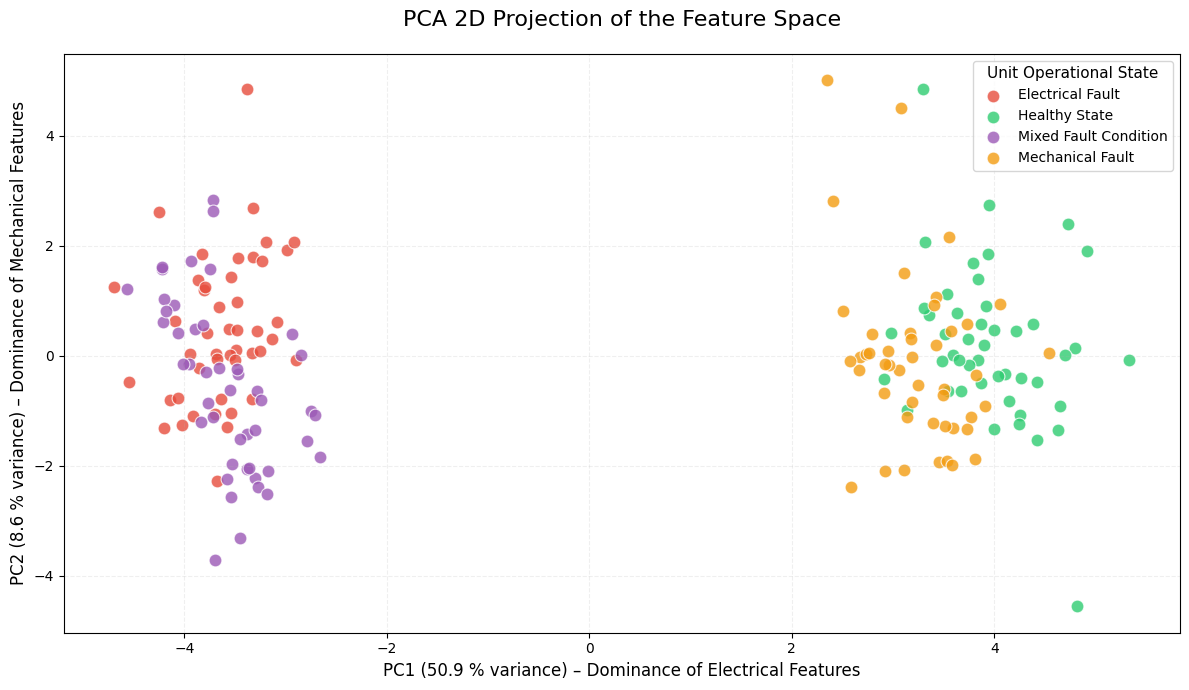

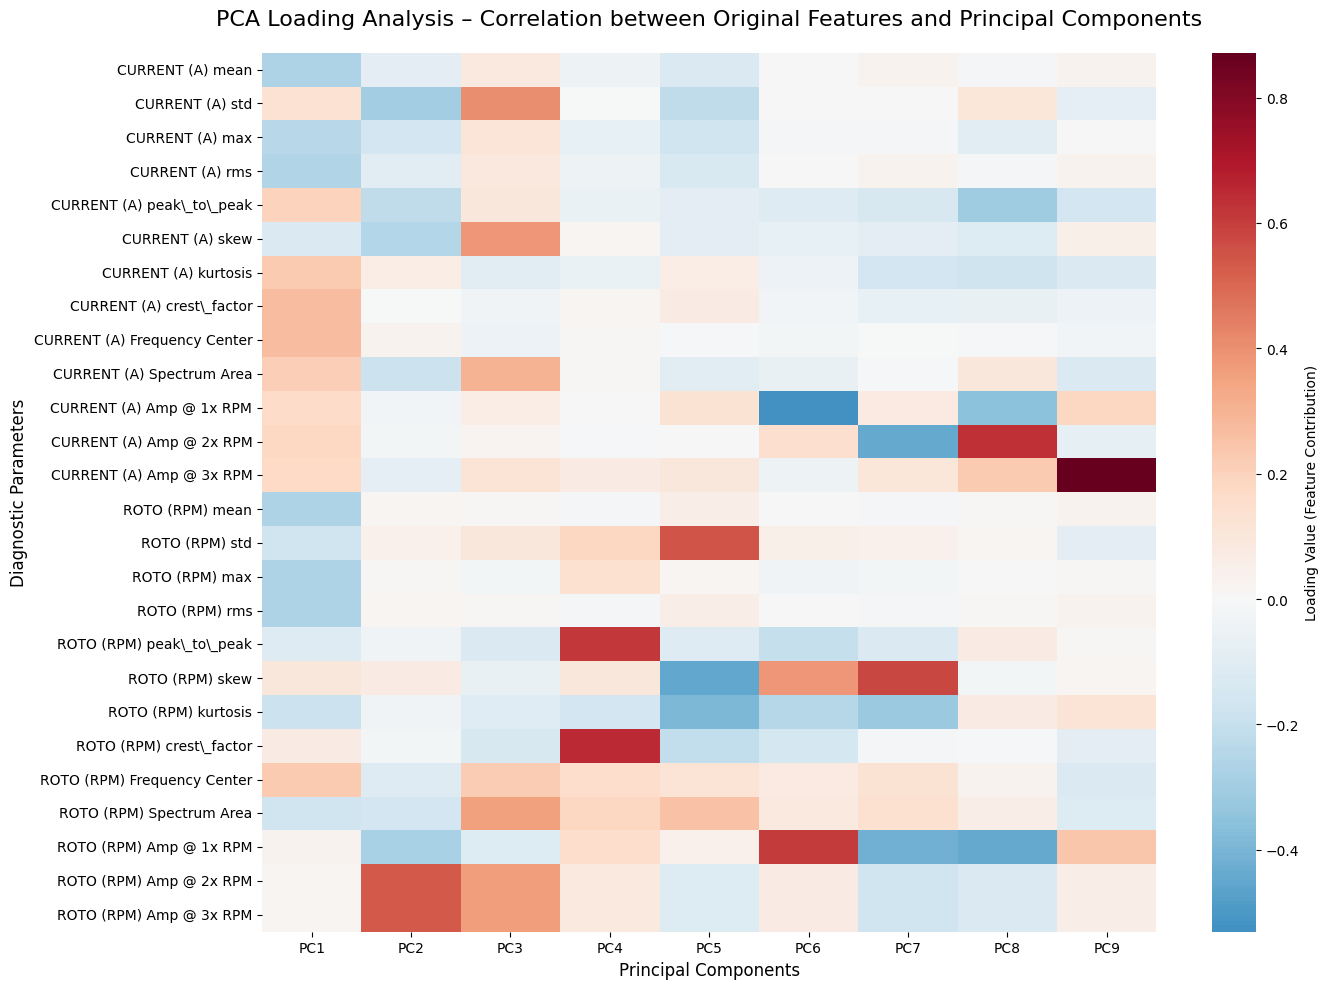

In [2]:
viz_mapping = {
    'Healthy': 'Healthy State',
    'Mech_Damage': 'Mechanical Fault',
    'Elec_Damage': 'Electrical Fault',
    'Mech_Elec_Damage': 'Mixed Fault Condition'
}

colors = {
    'Healthy State': '#2ecc71',
    'Mechanical Fault': '#f39c12',
    'Electrical Fault': '#e74c3c',
    'Mixed Fault Condition': '#9b59b6'
}

df_viz = df.copy()
df_viz['Class'] = df_viz['Class'].map(viz_mapping)

scaler_viz = StandardScaler()
X_scaled_viz = scaler_viz.fit_transform(X_fusion)

pca_viz = PCA(n_components=0.9, svd_solver='full')
X_pca_viz = pca_viz.fit_transform(X_scaled_viz)
explained_var = pca_viz.explained_variance_ratio_

plt.figure(figsize=(12, 7))

for cls in df_viz['Class'].unique():
    mask = df_viz['Class'] == cls
    plt.scatter(
        X_pca_viz[mask, 0], 
        X_pca_viz[mask, 1],
        c=colors[cls], 
        label=cls, 
        s=85, 
        alpha=0.8,
        edgecolors='white', 
        linewidth=0.8
    )

plt.title("PCA 2D Projection of the Feature Space", fontsize=16, pad=20)
plt.xlabel(f"PC1 ({explained_var[0]*100:.1f} % variance) – Dominance of Electrical Features", fontsize=12)
plt.ylabel(f"PC2 ({explained_var[1]*100:.1f} % variance) – Dominance of Mechanical Features", fontsize=12)
plt.legend(title="Unit Operational State", title_fontsize='11', fontsize='10', loc='best')
plt.grid(alpha=0.2, linestyle='--')
plt.tight_layout()
plt.show()

formatted_index = [col.replace('_', r'\_') for col in X_fusion.columns]

loadings = pd.DataFrame(
    pca_viz.components_.T,
    index=formatted_index,
    columns=[f"PC{i+1}" for i in range(pca_viz.n_components_)]
)

plt.figure(figsize=(14, 10))
sns.heatmap(loadings, cmap="RdBu_r", center=0, annot=False, 
            cbar_kws={'label': 'Loading Value (Feature Contribution)'})

plt.title("PCA Loading Analysis", fontsize=16, pad=20)
plt.xlabel("Principal Components", fontsize=12)
plt.ylabel("Diagnostic Parameters", fontsize=12)
plt.tight_layout()
plt.show()

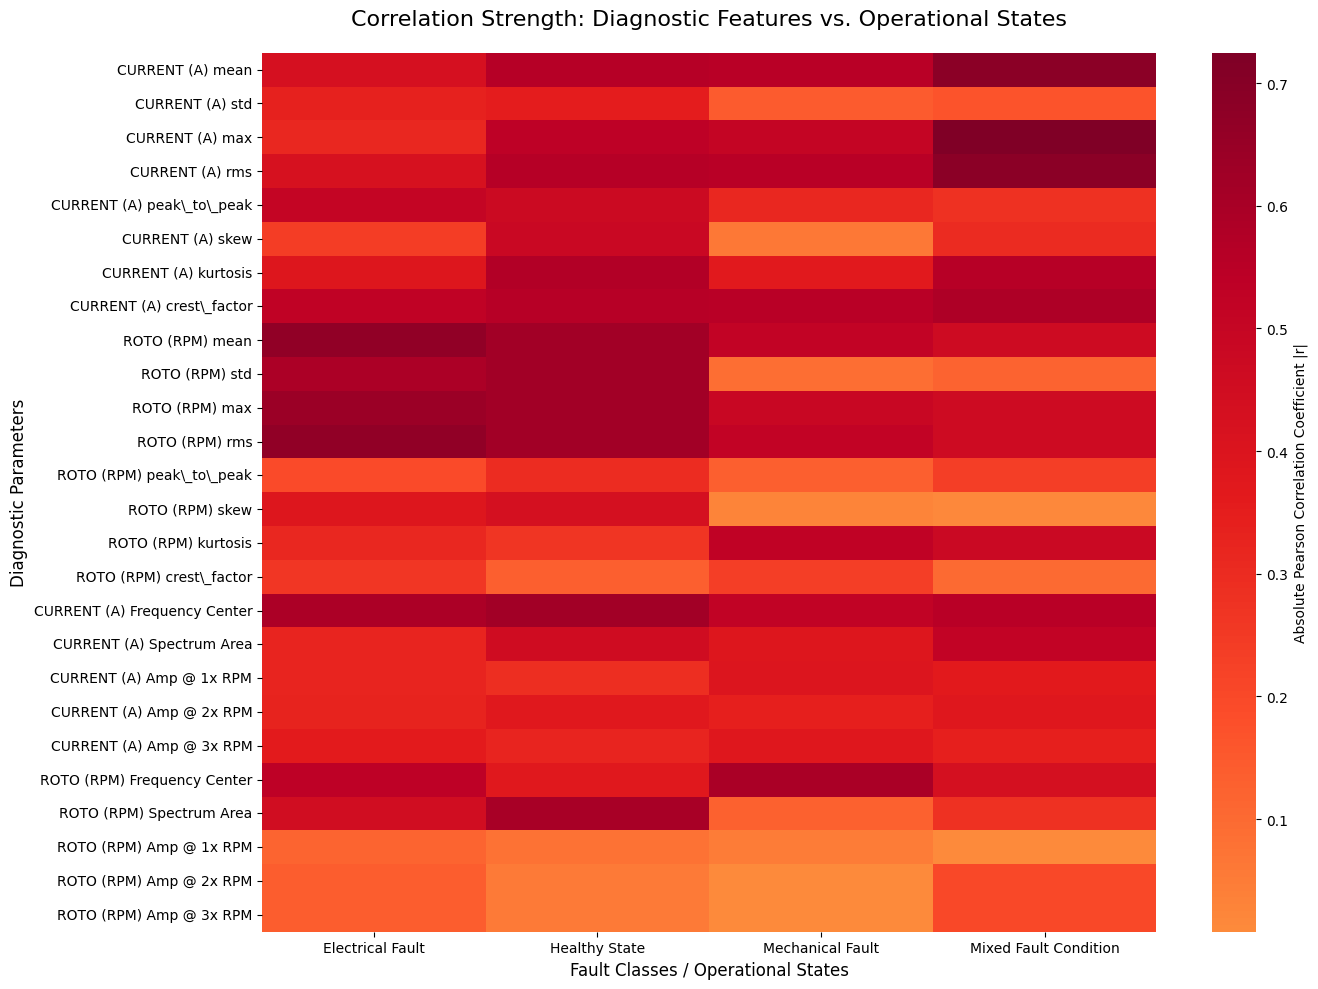

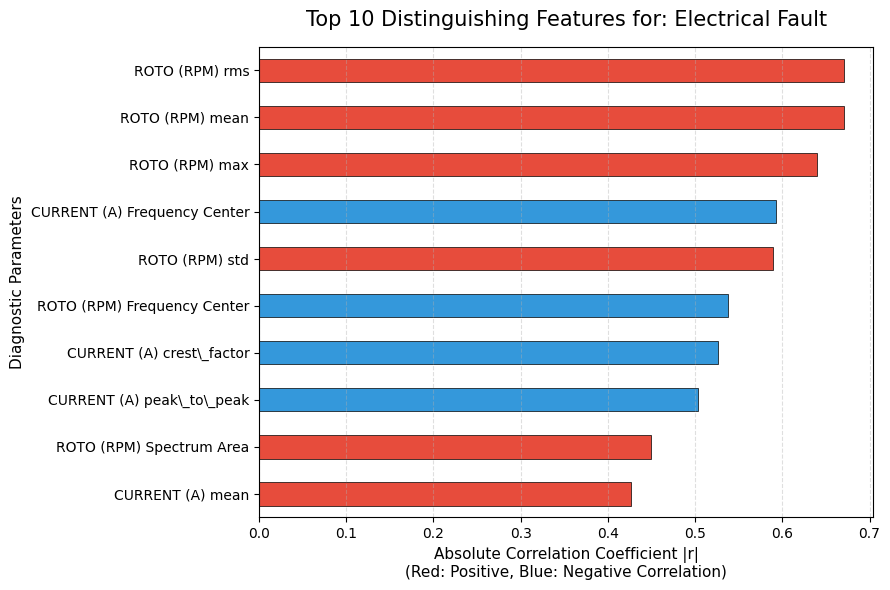

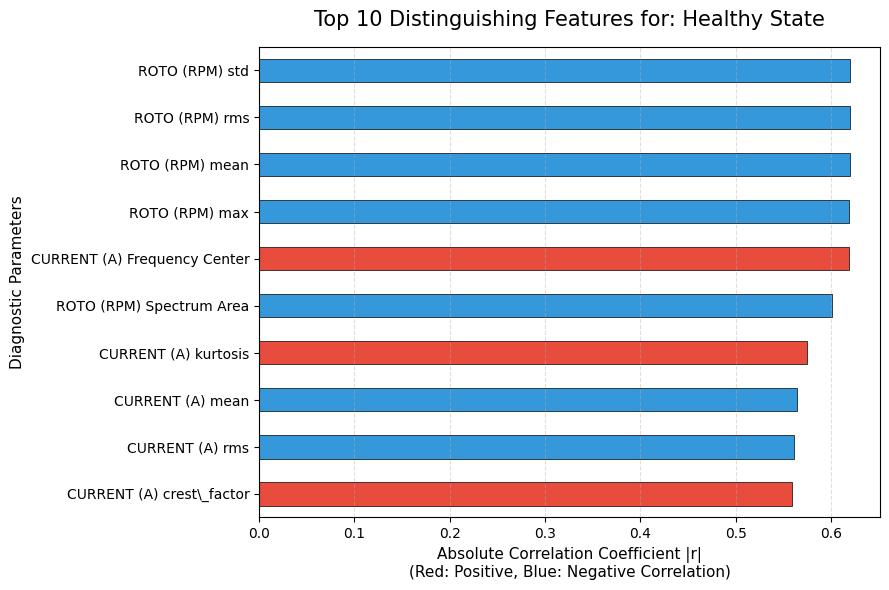

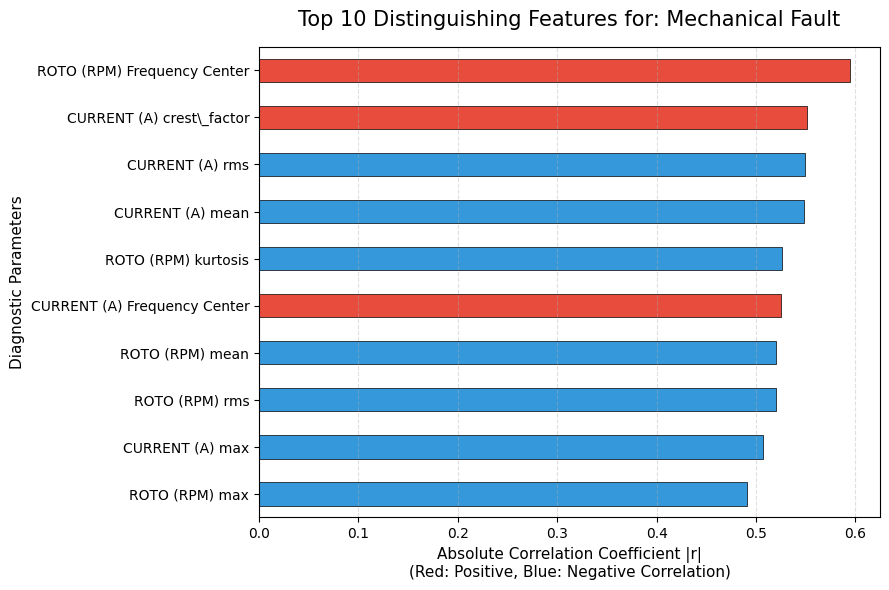

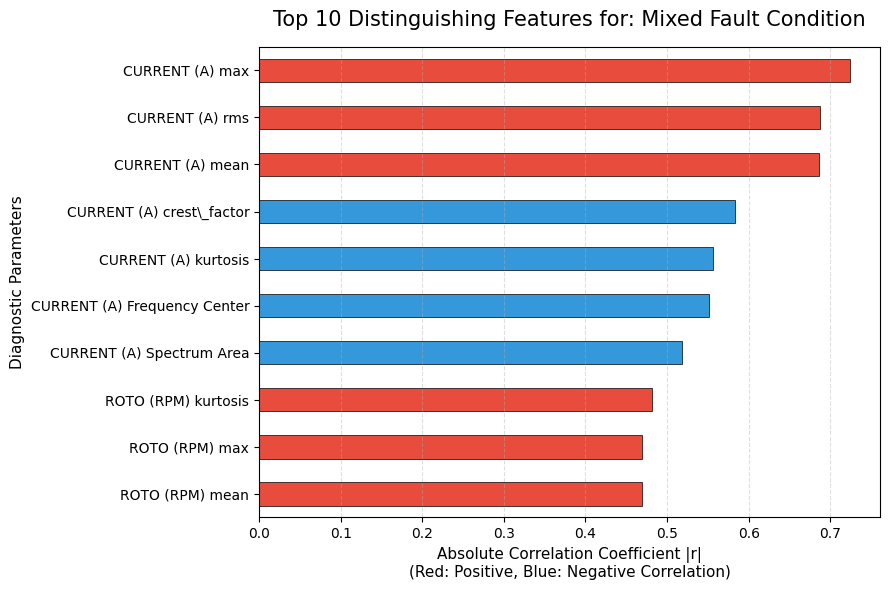

In [3]:
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
y_dummies = pd.get_dummies(df['Class'], prefix='is')
df_analysis = pd.concat([df[numeric_features], y_dummies], axis=1)

correlation_matrix = df_analysis.corr().loc[numeric_features, y_dummies.columns]

correlation_matrix.columns = [viz_mapping.get(col.replace('is_', ''), col.replace('is_', '')) 
                              for col in correlation_matrix.columns]
correlation_matrix.index = [idx.replace('_', r'\_') for idx in correlation_matrix.index]

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix.abs(), cmap="YlOrRd", center=0, annot=False, 
            cbar_kws={'label': 'Absolute Pearson Correlation Coefficient |r|'})
plt.title("Correlation Strength: Diagnostic Features vs. Operational States", fontsize=16, pad=20)
plt.ylabel("Diagnostic Parameters", fontsize=12)
plt.xlabel("Fault Classes / Operational States", fontsize=12)
plt.tight_layout()
plt.show()

top_n = 10
for class_name in correlation_matrix.columns:
    top_features = correlation_matrix[class_name].abs().sort_values(ascending=False).head(top_n)
    signs = correlation_matrix.loc[top_features.index, class_name]
    
    plt.figure(figsize=(9, 6))
    colors = ['#e74c3c' if val > 0 else '#3498db' for val in signs]
    top_features.plot(kind='barh', color=colors, edgecolor='black', linewidth=0.5)
    
    plt.title(f"Top {top_n} Distinguishing Features for: {class_name}", fontsize=15, pad=15)
    plt.xlabel("Absolute Correlation Coefficient |r|\n(Red: Positive, Blue: Negative Correlation)", fontsize=11)
    plt.ylabel("Diagnostic Parameters", fontsize=11)
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


Experiment: Mechanical vs Mixed | ACCURACY: 1.0000
                       precision    recall  f1-score   support

     Mechanical Fault       1.00      1.00      1.00        10
Mixed Fault Condition       1.00      1.00      1.00         9

             accuracy                           1.00        19
            macro avg       1.00      1.00      1.00        19
         weighted avg       1.00      1.00      1.00        19



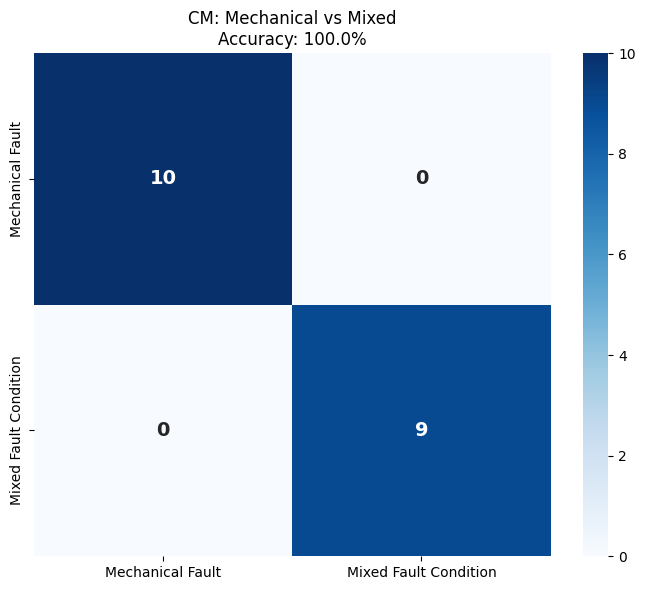

Mean Accuracy (Mechanical vs Mixed): 1.0000


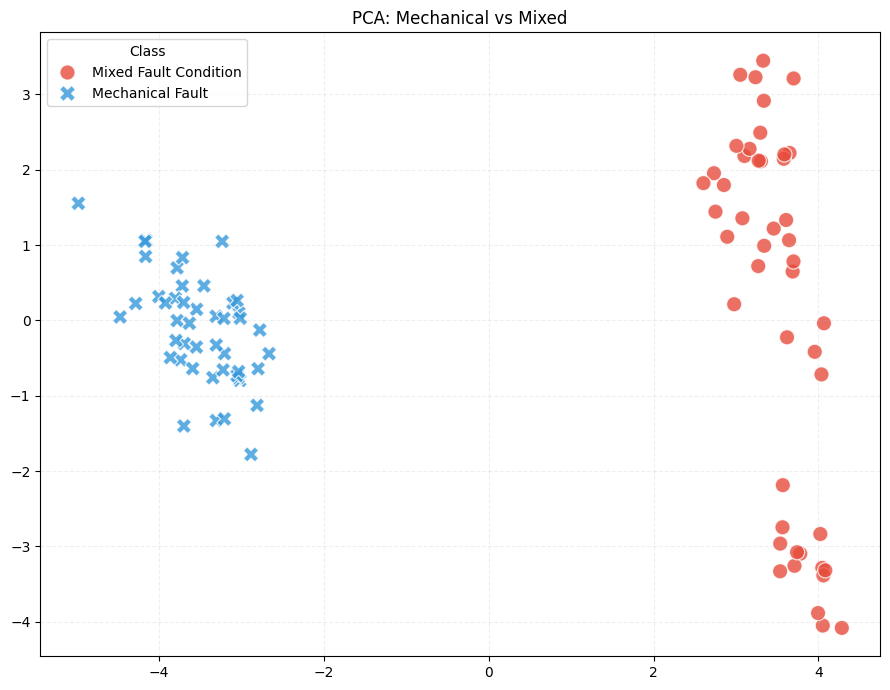


Experiment: Electrical vs Mixed | ACCURACY: 1.0000
                       precision    recall  f1-score   support

     Electrical Fault       1.00      1.00      1.00        10
Mixed Fault Condition       1.00      1.00      1.00         9

             accuracy                           1.00        19
            macro avg       1.00      1.00      1.00        19
         weighted avg       1.00      1.00      1.00        19



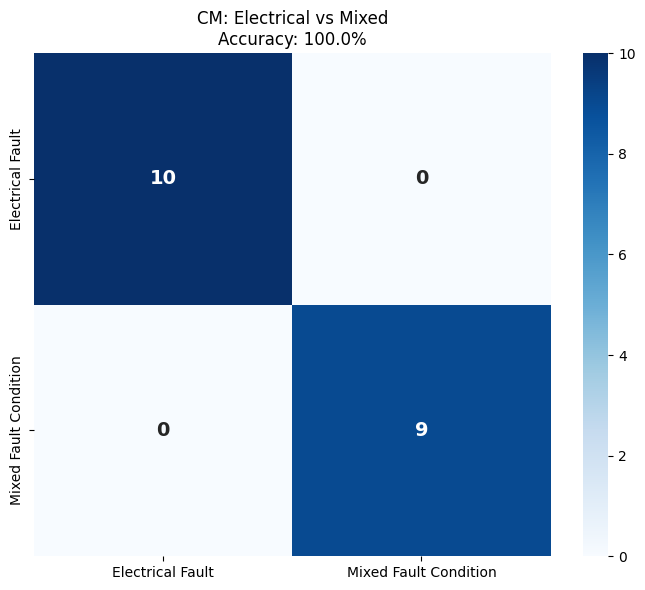

Mean Accuracy (Electrical vs Mixed): 1.0000


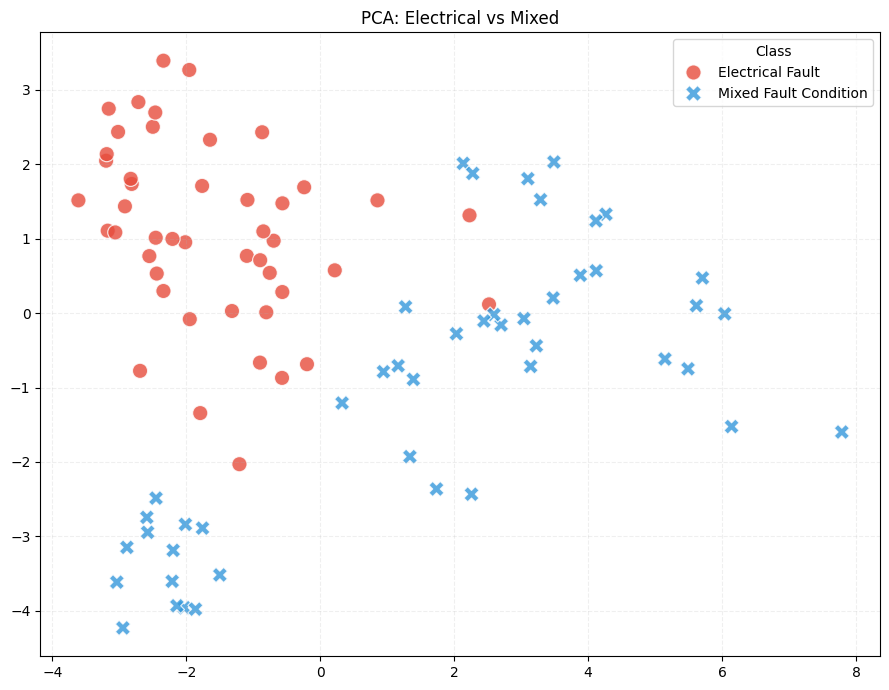

In [4]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def get_best_stacking_model():
    estimators = [
        ('rf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=1)),
        ('svm', make_pipeline(StandardScaler(), SVC(probability=True, kernel='rbf', random_state=42))),
        ('knn', make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, n_jobs=1)))
    ]
    
    return StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(),
        cv=5,
        n_jobs=1
    )

def analyze_subgroup(df_input, features, target_classes, experiment_name):
    df_sub = df_input[df_input["Class"].isin(target_classes)].copy()
    X = df_sub[features]
    y = df_sub["Class"]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    model = get_best_stacking_model()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"\nExperiment: {experiment_name} | ACCURACY: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7, 6))
    display_labels = [label.replace('_', ' ') for label in model.classes_]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=display_labels, yticklabels=display_labels,
                annot_kws={"size": 14, "weight": "bold"})
    plt.title(f"CM: {experiment_name}\nAccuracy: {acc*100:.1f}%")
    plt.tight_layout()
    plt.show()

def verify_subgroup_separation(df_input, labels, title):
    df_sub = df_input[df_input["Class"].isin(labels)].copy()
    X = df_sub[X_fusion.columns]
    y = df_sub["Class"]
    
    model = make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=100, random_state=42))
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    
    print(f"Mean Accuracy ({title}): {scores.mean():.4f}")
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    plt.figure(figsize=(9, 7))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, style=y, s=120, palette=['#e74c3c', '#3498db'], alpha=0.8)
    plt.title(f"PCA: {title}")
    plt.grid(True, alpha=0.2, linestyle='--')
    plt.tight_layout()
    plt.show()

df['Class'] = df['Class'].map(viz_mapping)

target_a = ["Mechanical Fault", "Mixed Fault Condition"]
analyze_subgroup(df, X_fusion.columns, target_a, "Mechanical vs Mixed")
verify_subgroup_separation(df, target_a, "Mechanical vs Mixed")

target_b = ["Electrical Fault", "Mixed Fault Condition"]
analyze_subgroup(df, X_fusion.columns, target_b, "Electrical vs Mixed")
verify_subgroup_separation(df, target_b, "Electrical vs Mixed")

C:\Users\Marek\AppData\Local\Temp\ipykernel_11552\221495020.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(TOP_N), x='Weight', y='Feature', palette='viridis', edgecolor='black', linewidth=0.5)


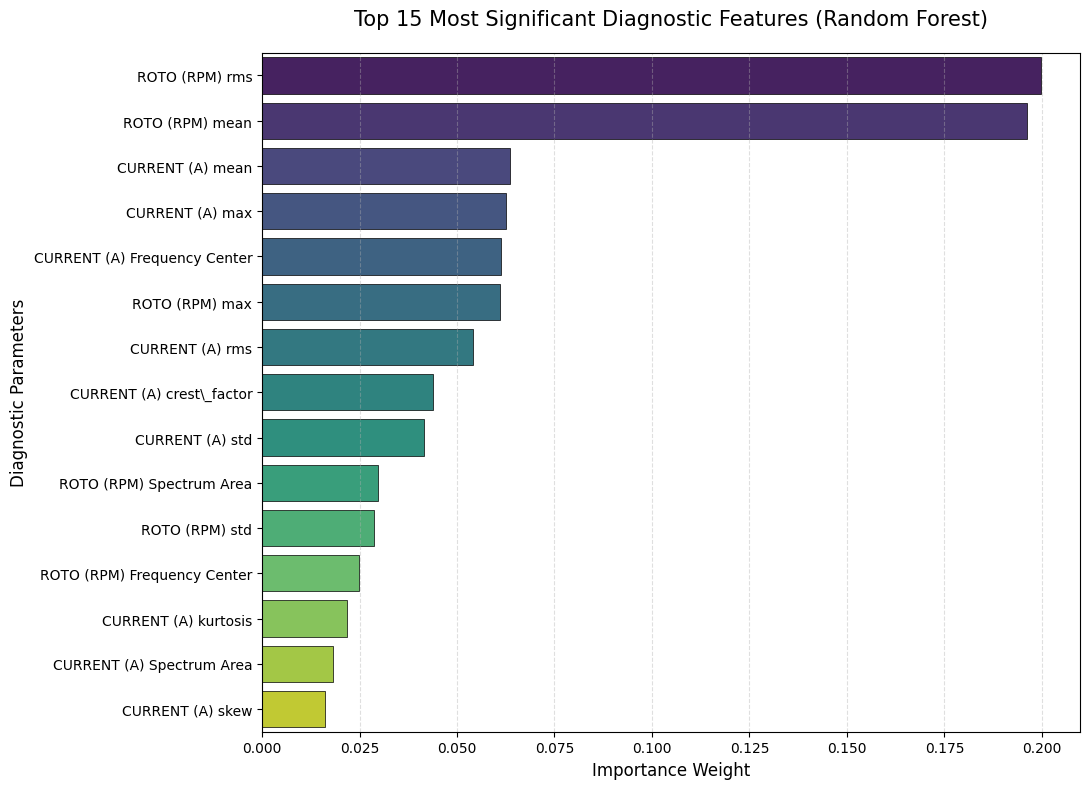

ACCURACY (Top 15): 0.9730
                       precision    recall  f1-score   support

     Electrical Fault       1.00      1.00      1.00         9
        Healthy State       0.90      1.00      0.95         9
     Mechanical Fault       1.00      0.90      0.95        10
Mixed Fault Condition       1.00      1.00      1.00         9

             accuracy                           0.97        37
            macro avg       0.97      0.97      0.97        37
         weighted avg       0.98      0.97      0.97        37



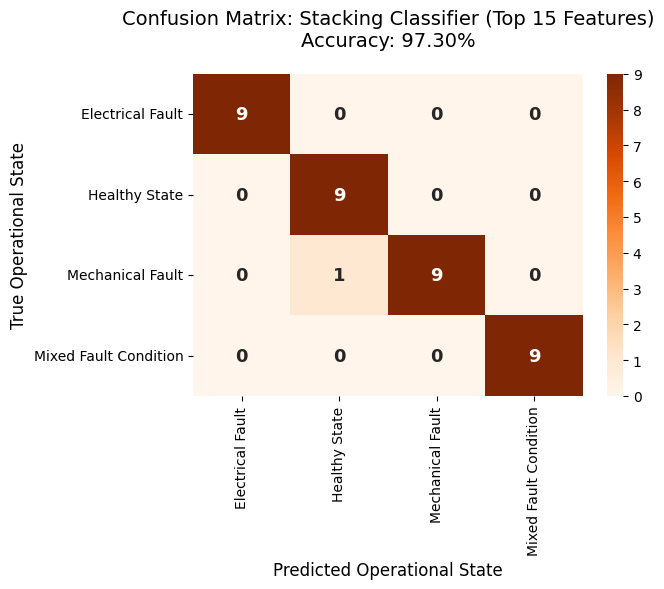

In [6]:
df = df.dropna(subset=['Class'])

rf_selector = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=1)
rf_selector.fit(X_fusion, df["Class"])

importances = pd.DataFrame({
    'Feature': [c.replace('_', r'\_') for c in X_fusion.columns],
    'Weight': rf_selector.feature_importances_
}).sort_values(by='Weight', ascending=False)

TOP_N = 15
plt.figure(figsize=(11, 8))
sns.barplot(data=importances.head(TOP_N), x='Weight', y='Feature', palette='viridis', edgecolor='black', linewidth=0.5)
plt.title(f"Top {TOP_N} Most Significant Diagnostic Features (Random Forest)", fontsize=15, pad=20)
plt.xlabel("Importance Weight", fontsize=12)
plt.ylabel("Diagnostic Parameters", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

top_features_original = [c.replace(r'\_', '_') for c in importances.head(TOP_N)['Feature']]
X_top = X_fusion[top_features_original]

X_train, X_test, y_train, y_test = train_test_split(
    X_top, df["Class"], test_size=0.2, random_state=42, stratify=df["Class"]
)

estimators = [
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=1)),
    ('svm', make_pipeline(StandardScaler(), SVC(probability=True, kernel='rbf', random_state=42))),
    ('knn', make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, n_jobs=1)))
]

clf_top = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=1
)

clf_top.fit(X_train, y_train)
y_pred_top = clf_top.predict(X_test)
acc_top = accuracy_score(y_test, y_pred_top)

print(f"ACCURACY (Top {TOP_N}): {acc_top:.4f}")
print(classification_report(y_test, y_pred_top))

cm = confusion_matrix(y_test, y_pred_top)
plt.figure(figsize=(7, 6))
display_labels = [label.replace('_', ' ') for label in clf_top.classes_]
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=display_labels, yticklabels=display_labels,
            annot_kws={"size": 13, "weight": "bold"})
plt.title(f"Confusion Matrix: Stacking Classifier (Top {TOP_N} Features)\nAccuracy: {acc_top*100:.2f}%", fontsize=14, pad=20)
plt.ylabel('True Operational State', fontsize=12)
plt.xlabel('Predicted Operational State', fontsize=12)
plt.tight_layout()
plt.show()

---------------------------------------------------------------------------
SEED   | MODEL                          | ACCURACY   | F1-MACRO  
---------------------------------------------------------------------------
42     | Random Forest (Raw Features)   | 0.9730     | 0.9737
42     | Random Forest + PCA            | 0.9189     | 0.9194
1      | Random Forest (Raw Features)   | 0.9459     | 0.9460
1      | Random Forest + PCA            | 0.7027     | 0.6936
7      | Random Forest (Raw Features)   | 0.9730     | 0.9721
7      | Random Forest + PCA            | 0.8378     | 0.8338
10     | Random Forest (Raw Features)   | 0.9459     | 0.9472
10     | Random Forest + PCA            | 0.7838     | 0.7834
21     | Random Forest (Raw Features)   | 1.0000     | 1.0000
21     | Random Forest + PCA            | 0.8378     | 0.8347
50     | Random Forest (Raw Features)   | 0.9730     | 0.9721
50     | Random Forest + PCA            | 0.8649     | 0.8639
100    | Random Forest (Raw Features) 

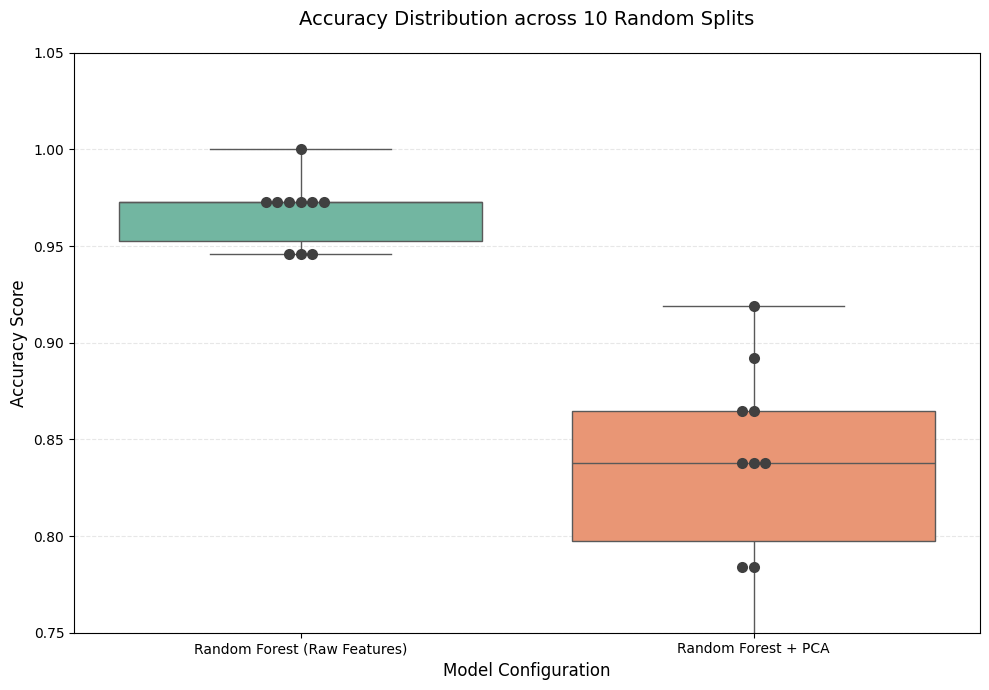

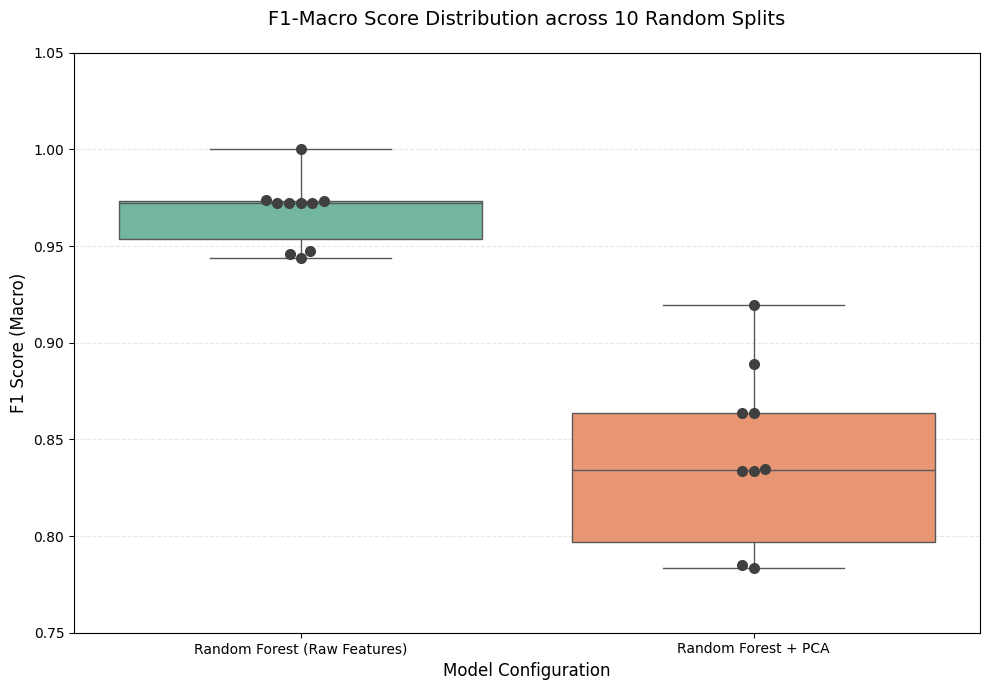

In [21]:
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

file_path = "motors.csv"

df = pd.read_csv(file_path, sep=None, engine='python')

df = df.drop(columns=[c for c in df.columns if c.startswith("is_") or "Unnamed" in c], errors="ignore")

def map_to_elegant_name(name):
    name = str(name).strip().lower()
    if 'healthy' in name:
        return 'Healthy State'
    elif ('elec' in name and 'mech' in name) or 'mixed' in name:
        return 'Mixed Fault Condition'
    elif 'elec' in name:
        return 'Electrical Fault'
    elif 'mech' in name:
        return 'Mechanical Fault'
    return None

df['Class'] = df['Class'].apply(map_to_elegant_name)
df = df.dropna(subset=['Class'])

if df.empty:
    raise ValueError("The dataset is empty after mapping! Please check your CSV class names.")

feature_cols = [c for c in df.columns if "CURRENT" in c.upper() or "ROTO" in c.upper()]
X = df[feature_cols]
y = df["Class"]

seeds = [42, 1, 7, 10, 21, 50, 100, 123, 777, 2024]
results_seeds = []

print("-" * 75)
print(f"{'SEED':<6} | {'MODEL':<30} | {'ACCURACY':<10} | {'F1-MACRO':<10}")
print("-" * 75)

for seed in seeds:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    raw_model_name = "Random Forest (Raw Features)"
    rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=1)
    rf.fit(X_train_s, y_train)
    y_pred = rf.predict(X_test_s)
    
    results_seeds.append({
        "Seed": seed,
        "Model": raw_model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred, average='macro'),
        "F1": f1_score(y_test, y_pred, average='macro')
    })
    
    print(f"{seed:<6} | {raw_model_name:<30} | {accuracy_score(y_test, y_pred):.4f}     | {f1_score(y_test, y_pred, average='macro'):.4f}")

    pca_model_name = "Random Forest + PCA"
    pca = PCA(n_components=0.9, svd_solver='full')
    X_train_p = pca.fit_transform(X_train_s)
    X_test_p = pca.transform(X_test_s)
    
    rf_pca = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=1)
    rf_pca.fit(X_train_p, y_train)
    y_pred_p = rf_pca.predict(X_test_p)
    
    results_seeds.append({
        "Seed": seed,
        "Model": pca_model_name,
        "Accuracy": accuracy_score(y_test, y_pred_p),
        "Recall": recall_score(y_test, y_pred_p, average='macro'),
        "F1": f1_score(y_test, y_pred_p, average='macro')
    })
    print(f"{seed:<6} | {pca_model_name:<30} | {accuracy_score(y_test, y_pred_p):.4f}     | {f1_score(y_test, y_pred_p, average='macro'):.4f}")

df_seeds = pd.DataFrame(results_seeds)
summary = df_seeds.groupby("Model").agg(['mean', 'std'])[["Accuracy", "F1", "Recall"]]

print("\n\nSTATISTICAL SUMMARY (Mean +/- Standard Deviation)")
print(summary)

plt.figure(figsize=(10, 7))
sns.boxplot(data=df_seeds, x="Model", y="Accuracy", hue="Model", legend=False, palette="Set2")
sns.swarmplot(data=df_seeds, x="Model", y="Accuracy", color=".25", size=8)

plt.title(f"Accuracy Distribution across {len(seeds)} Random Splits", fontsize=14, pad=20)
plt.ylabel("Accuracy Score", fontsize=12)
plt.xlabel("Model Configuration", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0.75, 1.05)
plt.tight_layout()

plt.savefig('Statistical_Comparison_Accuracy_EN.png', dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 7))
sns.boxplot(data=df_seeds, x="Model", y="F1", hue="Model", legend=False, palette="Set2")
sns.swarmplot(data=df_seeds, x="Model", y="F1", color=".25", size=8)

plt.title(f"F1-Macro Score Distribution across {len(seeds)} Random Splits", fontsize=14, pad=20)
plt.ylabel("F1 Score (Macro)", fontsize=12)
plt.xlabel("Model Configuration", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0.75, 1.05)
plt.tight_layout()

plt.savefig('Statistical_Comparison_F1_EN.png', dpi=200, bbox_inches='tight')
plt.show()

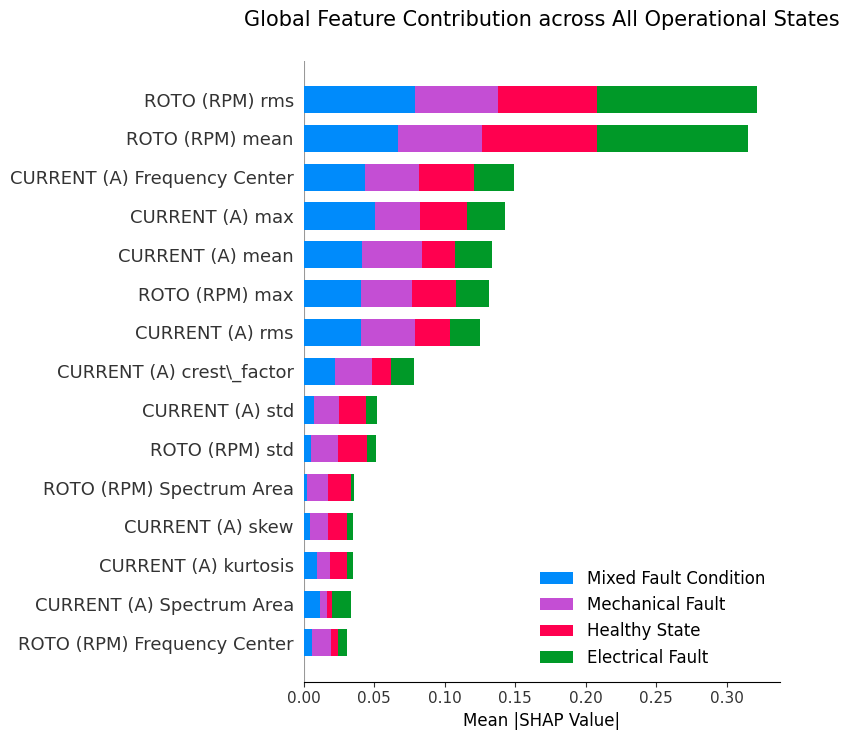

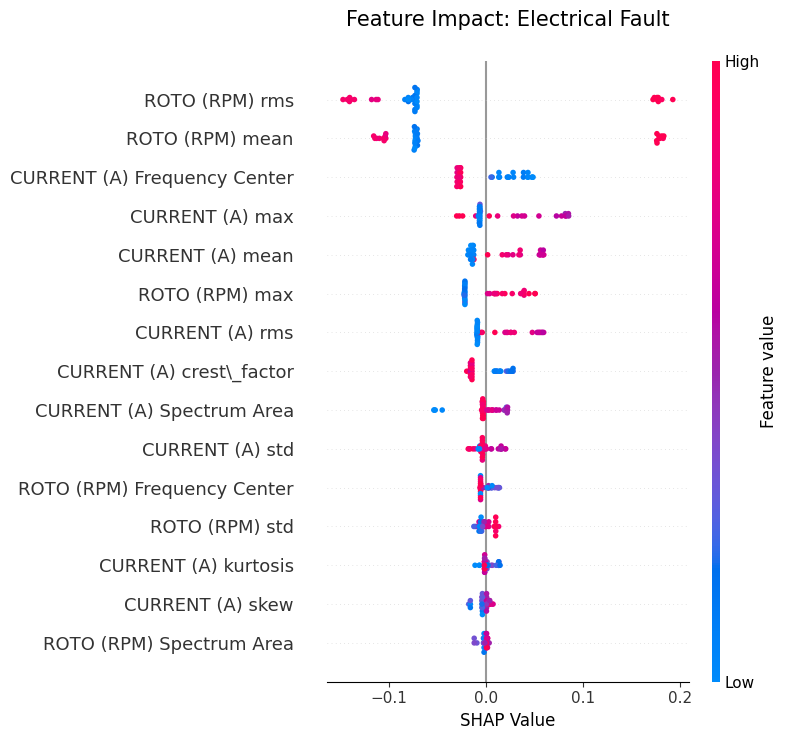

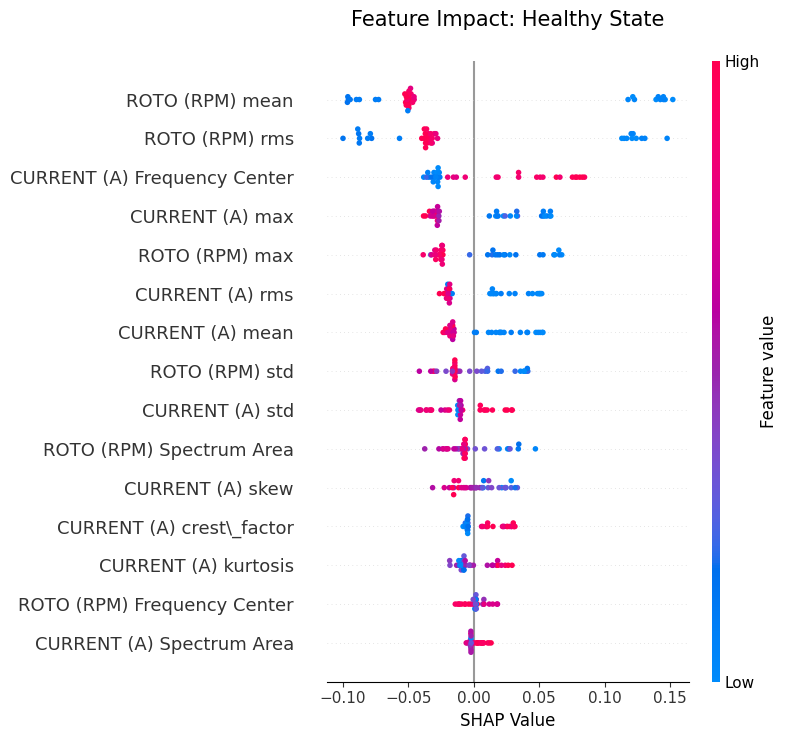

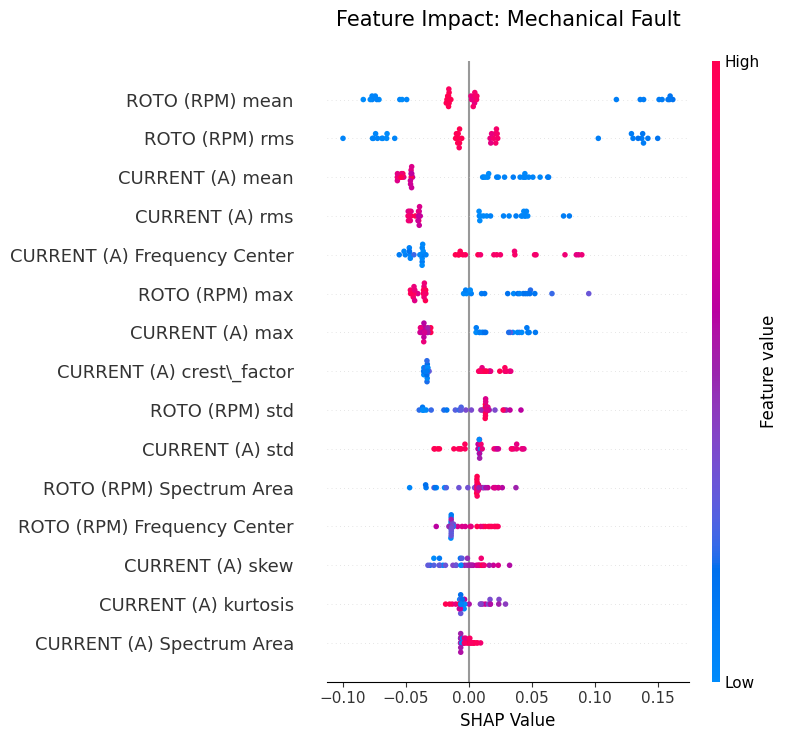

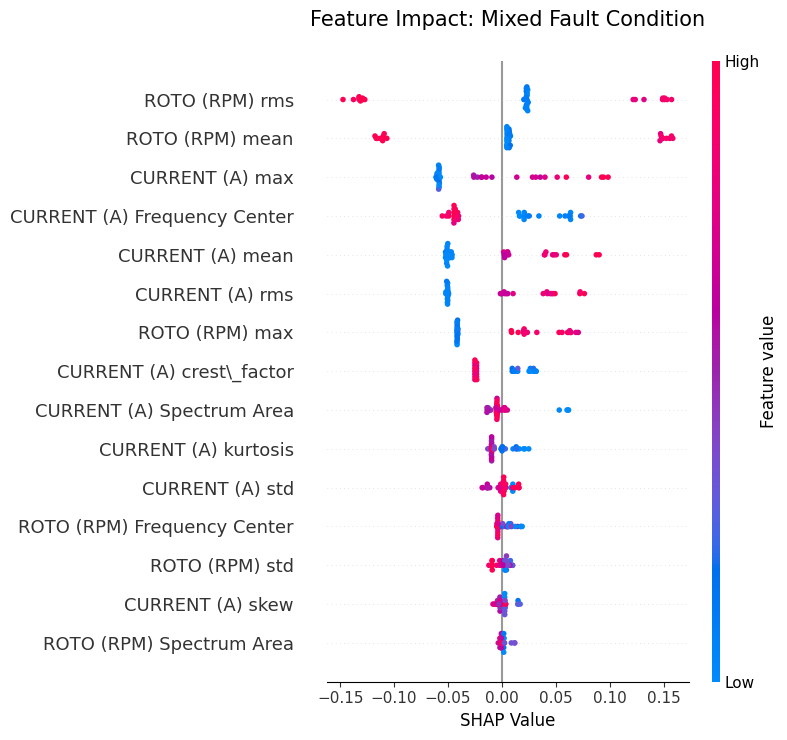

In [16]:
import shap

top_15_features = [
    'ROTO (RPM) rms', 'ROTO (RPM) mean', 'CURRENT (A) mean', 'CURRENT (A) max', 
    'CURRENT (A) Frequency Center', 'ROTO (RPM) max', 'CURRENT (A) rms', 
    'CURRENT (A) crest_factor', 'CURRENT (A) std', 'ROTO (RPM) Spectrum Area', 
    'ROTO (RPM) std', 'ROTO (RPM) Frequency Center', 'CURRENT (A) kurtosis', 
    'CURRENT (A) Spectrum Area', 'CURRENT (A) skew'
]

X_top = df[top_15_features]
X_top.columns = [col.replace('_', r'\_') for col in X_top.columns]

X_train, X_test, y_train, y_test = train_test_split(
    X_top, df["Class"], test_size=0.2, random_state=42, stratify=df["Class"]
)

model_for_shap = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1)
model_for_shap.fit(X_train, y_train)

explainer = shap.TreeExplainer(model_for_shap)
shap_values = explainer.shap_values(X_test, check_additivity=False)

if isinstance(shap_values, list):
    shap_values_plot = shap_values
else:
    shap_values_plot = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_plot, 
    X_test, 
    class_names=model_for_shap.classes_, 
    plot_type="bar", 
    show=False
)
plt.title("Global Feature Contribution across All Operational States", fontsize=15, pad=25)
plt.xlabel("Mean |SHAP Value|", fontsize=12)
plt.tight_layout()
plt.show()

for class_idx, class_name in enumerate(model_for_shap.classes_):
    if isinstance(shap_values, list):
        shap_val_class = shap_values[class_idx]
    else:
        shap_val_class = shap_values[:, :, class_idx]
        
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_val_class, X_test, show=False)
    plt.title(f"Feature Impact: {class_name}", fontsize=15, pad=25)
    plt.xlabel("SHAP Value", fontsize=12)
    plt.tight_layout()
    plt.show()

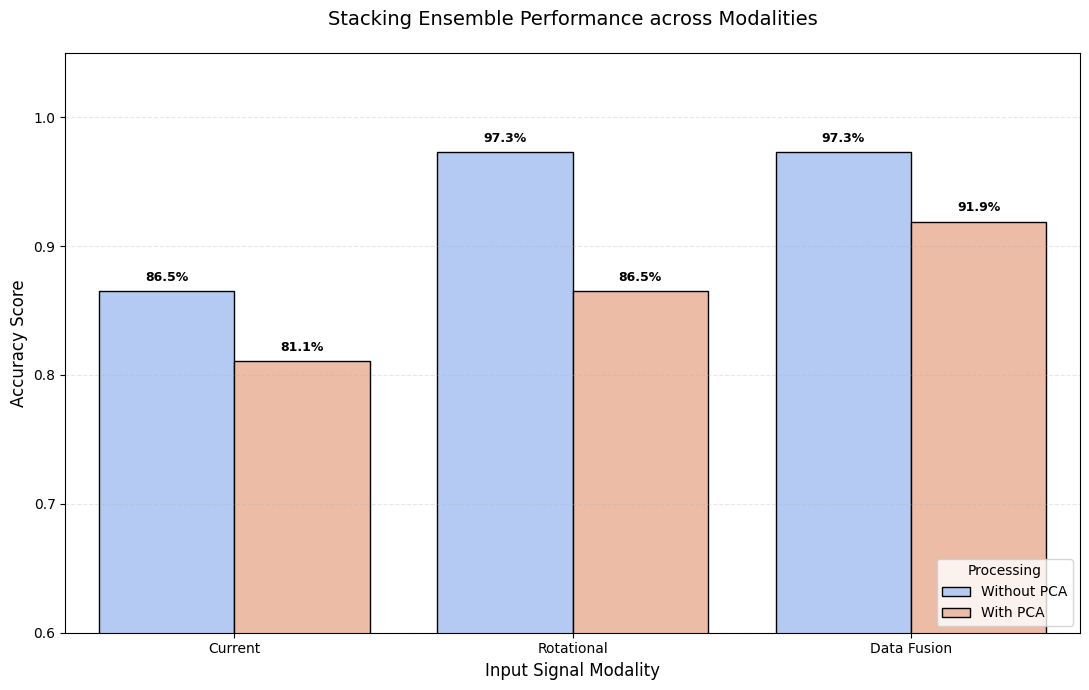

In [18]:

def get_rf_stacking_model():
    estimators = [
        ('rf_std', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=1)),
        ('rf_shallow', RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, n_jobs=1)),
        ('rf_dense', RandomForestClassifier(n_estimators=500, min_samples_split=2, random_state=42, n_jobs=1))
    ]
    return StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=1000),
        cv=5, n_jobs=1
    )

datasets = {
    "Current": df[current_cols],
    "Rotational": df[roto_cols],
    "Data Fusion": X_fusion
}

results = []

for name, X_data in datasets.items():
    if X_data.shape[1] == 0: continue 

    X_train, X_test, y_train, y_test = train_test_split(
        X_data, df['Class'], test_size=0.2, random_state=42, stratify=df['Class']
    )
    
    model = get_rf_stacking_model()
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    results.append({"Modality": name, "Processing": "Without PCA", "Accuracy": acc})
    
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_train)
    X_te_s = scaler.transform(X_test)
    pca = PCA(n_components=0.9)
    X_tr_p = pca.fit_transform(X_tr_s)
    X_te_p = pca.transform(X_te_s)
    
    model_p = get_rf_stacking_model()
    model_p.fit(X_tr_p, y_train)
    acc_p = accuracy_score(y_test, model_p.predict(X_te_p))
    results.append({"Modality": name, "Processing": "With PCA", "Accuracy": acc_p})

df_res = pd.DataFrame(results)
plt.figure(figsize=(11, 7))
sns.barplot(data=df_res, x="Modality", y="Accuracy", hue="Processing", palette="coolwarm", edgecolor='black')

plt.ylim(0.6, 1.05)
plt.title("Stacking Ensemble Performance across Modalities", fontsize=14, pad=20)
plt.ylabel("Accuracy Score", fontsize=12)
plt.xlabel("Input Signal Modality", fontsize=12)
plt.legend(title="Processing", loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(f'{p.get_height()*100:.1f}%', 
                           (p.get_x() + p.get_width() / 2., p.get_height()), 
                           ha='center', va='center', xytext=(0, 10), 
                           textcoords='offset points', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()